# **Working with combination of two or many strategies**

> **Meausers to reduce trading costs:**
1. Busy trading hours.
2. Right Granularity.
3. Better and complex strategies with stronger signals.
4. Stay neutral if signals are weak.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from itertools import product

In [ ]:
class SMABackTester():      # Creating a class
  def __init__(self,company_symbol,period,interval,SMA_S,SMA_L):
    self.company_symbol=company_symbol
    self.period=period
    self.interval=interval
    self.SMA_S=SMA_S
    self.SMA_L=SMA_L
    self.result={}
    self.get_data()
    self.calculate_data()

  # Method: get_data()
  def get_data(self):
    stock=yf.download(tickers=self.company_symbol,period=self.period,interval= self.interval,auto_adjust=True)
    self.df=pd.DataFrame(stock["Close"])

  # Method: calculate_date():
  def calculate_data(self):
    for symbol in self.company_symbol:
      self.df[f"LR {symbol}"]=np.log(self.df[symbol]/self.df[symbol].shift(1))
      self.df[f"SMA_L {symbol}"]=self.df[symbol].rolling(window=self.SMA_L).mean()
      self.df[f"SMA_S {symbol}"]=self.df[symbol].rolling(window=self.SMA_S).mean()
      self.df.dropna(inplace=True)
      self.result[symbol] = self.df
    return self.df.dropna()

  # Method: set_parameters():Will be used for multiple combination of SMA_S & SMA_L
  def set_SMA_SnL(self,SMA_S=None,SMA_L=None):
    if self.SMA_S is not None:
      self.SMA_S=SMA_S
    if self.SMA_L is not None:
      self.SMA_L=SMA_L
    self.calculate_data()

  # Method: test_strategy(): will test the position and strategy for all SMA_S & SMA_L combination.
  def test_strategy(self):
    for symbol in self.company_symbol:
      self.df[f"Signal {symbol}"]=np.where(self.df[f"SMA_S {symbol}"]>self.df[f"SMA_L {symbol}"],1,-1)
      self.df[f"Strategy {symbol}"]=self.df[f"Signal {symbol}"].shift(1)*self.df[f"LR {symbol}"]
      self.df.dropna(inplace=True)
      self.df[f"Cumulative Return {symbol}"]=np.exp(self.df[f"LR {symbol}"].cumsum())
      self.df[f"Cumulative Strategy {symbol}"]=np.exp(self.df[f"Strategy {symbol}"].cumsum())
    return self.df.dropna()

  # Method: plot_result(): Will plot the results of the strategy for every ticker symbol
  def plot_result(self,ticker=None):
    if ticker is None:
      to_plot=self.company_symbol
    elif isinstance(ticker,str):
      to_plot=[ticker]
    else:
      to_plot=ticker
    for symbol in to_plot:
      if self.df[symbol] is None:
        print(f"Run the test_strategy() for {symbol} 1st!")
      else:
        fig,(ax1,ax2)=plt.subplots(2,1,figsize=(12,8),sharex=True)
        ax1.plot(self.df.index, self.df[symbol], label="Price", alpha=0.5)
        ax1.plot(self.df.index, self.df[f"SMA_S {symbol}"], label=f"SMA_S ({self.SMA_S})", color="orange")
        ax1.plot(self.df.index, self.df[f"SMA_L {symbol}"], label=f"SMA_L ({self.SMA_L})", color="blue")
        ax1.set_title(f"{symbol} - SMA Crossover")
        ax1.set_ylabel("Price")
        ax1.legend()
        ax2.plot(self.df.index, self.df[f"Cumulative Strategy {symbol}"], label="Strategy Performance", color="green")
        ax2.plot(self.df.index, self.df[f"Cumulative Return {symbol}"], label="Buy & Hold", color="gray", linestyle="--")
        ax2.set_ylabel("Growth ($1 Invested)")
        ax2.legend()
        plt.show()

  # Method: optimize_para(): make combination of SMA_S & SMA_L for different strategy output check
  def optimize_para(self,SMA_S_range,SMA_L_range):
    # making the combinations
    combination=list(product(range(*SMA_S_range),range(*SMA_L_range)))
    performance=[]
    for comb in combination:
      s,l=comb
      if s>l:
        continue
      self.set_parameters(s,l)
      # Access the result for the first company symbol and get the last 'Cumulative Strategy' value
      # Assuming optimization is based on the first company in the list
      df_first_company_result = self.test_strategy()[self.company_symbol[0]]
      performance.append(df_first_company_result["Cumulative Strategy"].iloc[-1])
    best_perf=np.max(performance)    # find best score
    opt=combination[np.argmax(performance)]    # find the SMA_S & SMA_L which gave the best score
    # Testing the best strategy by using optimal parameter (SMA_S & SMA_L)
    self.set_parameters(opt[0],opt[1])
    self.test_strategy()
    return self.performance

In [ ]:
stk=SMABackTester(["HAL.NS","BEL.NS"],period="2y",interval="1d",SMA_L=30,SMA_S=7)
stk.calculate_data()
stk.test_strategy()

In [ ]:
stk.plot_result("HAL.NS")

In [ ]:
class BolingerBands():
  def __init__(self, company,period,interval):
    self.company=company
    self.period=period
    self.interval=interval
    self.get_data()

  def get_data(self):
    data=yf.download(self.company,period=self.period,interval=self.interval,auto_adjust=True)
    self.df=pd.DataFrame(data["Close"])
    return self.df

  def calculate_data(self):
    SMA=7;deviation=2;ptc=0.00007
    for ticker in self.company:
      self.df[f"LR {ticker}"]=np.log(self.df[ticker]/self.df[ticker].shift(1))
      self.df[f"SMA {ticker}"]=self.df[ticker].rolling(SMA).mean()
      # Corrected Bollinger Band calculation:
      self.df[f"Lower {ticker}"]=self.df[f"SMA {ticker}"] - (self.df[ticker].rolling(SMA).std()*deviation)
      self.df[f"Upper {ticker}"]=self.df[f"SMA {ticker}"] + (self.df[ticker].rolling(SMA).std()*deviation)
      self.df[f"Distance {ticker}"]=self.df[ticker]-self.df[f"SMA {ticker}"]
      conditions = [self.df[ticker] < self.df[f"Lower {ticker}"], # Buy if price is below the lower band
          self.df[ticker] > self.df[f"Upper {ticker}"] ] # Sell if price is above the upper band
      choices = [1, -1] # Corresponding choices for the conditions
      self.df[f"Position {ticker}"] = np.select(conditions, choices, default=0) # Default to 0 (neutral) if no conditions met

      self.df[f"Strategy {ticker}"]=self.df[f"Position {ticker}"].shift(1)*self.df[f"LR {ticker}"]
      self.df[f"Cumulative Return {ticker}"]=np.exp(self.df[f"LR {ticker}"].cumsum())
      self.df[f"Cumulative Strategy {ticker}"]=np.exp(self.df[f"Strategy {ticker}"].cumsum())
      self.df[f"Trades {ticker}"]=self.df[f"Position {ticker}"].diff().fillna(0).abs()
      self.df[f"Net_Strategy {ticker}"]=self.df[f"Strategy {ticker}"]-self.df[f"Trades {ticker}"]*ptc
      self.df[f"Cumulative Net_Strategy {ticker}"]=np.exp(self.df[f"Net_Strategy {ticker}"].cumsum())
    return self.df.dropna()

  def plot_data(self):
    for ticker in self.company:
      self.df[[f"{ticker}",f"SMA {ticker}",f"Lower {ticker}",f"Upper {ticker}"]].plot(figsize=(15,6),fontsize=12)
      plt.legend(fontsize=12)
      plt.show()
      self.df[[f"Cumulative Return {ticker}",f"Cumulative Strategy {ticker}"]].plot(figsize=(15,6),fontsize=12,title=f"Cumulative Result of {ticker}")
      plt.legend(fontsize=12)
      plt.show()
      self.df[[f"Cumulative Strategy {ticker}",f"Cumulative Net_Strategy {ticker}"]].plot(figsize=(15,6),fontsize=12,title=f"Cumulative Result of {ticker}")
      plt.legend(fontsize=12)
      plt.show()

  def ann_result(self):
    ann_return=[];ann_risk=[]
    for ticker in self.company:
      ann_return.append(self.df[[f"LR {ticker}",f"Net_Strategy {ticker}"]].mean()*(4*252))
      ann_risk.append(self.df[[f"LR {ticker}",f"Net_Strategy {ticker}"]].std()*np.sqrt(4*252))
    print(f"Annual Returns of companies = {ann_return}")
    print(f"Annual Risks of companies = {ann_risk}")

In [133]:
str1=BolingerBands(company=["BSE.NS"],period="3y",interval="1d")
str1.calculate_data()

[*********************100%***********************]  1 of 1 completed


Ticker,BSE.NS,LR BSE.NS,SMA BSE.NS,Lower BSE.NS,Upper BSE.NS,Distance BSE.NS,Position BSE.NS,Strategy BSE.NS,Cumulative Return BSE.NS,Cumulative Strategy BSE.NS,Trades BSE.NS,Net_Strategy BSE.NS,Cumulative Net_Strategy BSE.NS
Date,,,,,,,,,,,,,
2023-02-27,141.937759,-0.008114,148.243003,138.119749,158.366256,-6.305243,0,-0.0,0.917368,1.000000,0.0,-0.0,1.000000
2023-02-28,143.566422,0.011409,146.649242,137.862009,155.436475,-3.082820,0,0.0,0.927895,1.000000,0.0,0.0,1.000000
2023-03-01,144.820480,0.008697,145.539427,138.455982,152.622871,-0.718946,0,0.0,0.936000,1.000000,0.0,0.0,1.000000
2023-03-02,144.429626,-0.002703,144.387732,140.840103,147.935362,0.041894,0,-0.0,0.933474,1.000000,0.0,-0.0,1.000000
2023-03-03,146.041977,0.011102,144.189965,141.348829,147.031102,1.852012,0,0.0,0.943895,1.000000,0.0,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-11,3177.100098,0.000913,2983.242885,2709.592713,3256.893057,193.857213,0,0.0,20.534150,0.814993,0.0,0.0,0.812487
2026-02-12,3143.199951,-0.010727,3023.585728,2750.910311,3296.261146,119.614223,0,-0.0,20.315047,0.814993,0.0,-0.0,0.812487
2026-02-13,3025.300049,-0.038231,3042.014300,2793.080796,3290.947804,-16.714251,0,-0.0,19.553040,0.814993,0.0,-0.0,0.812487


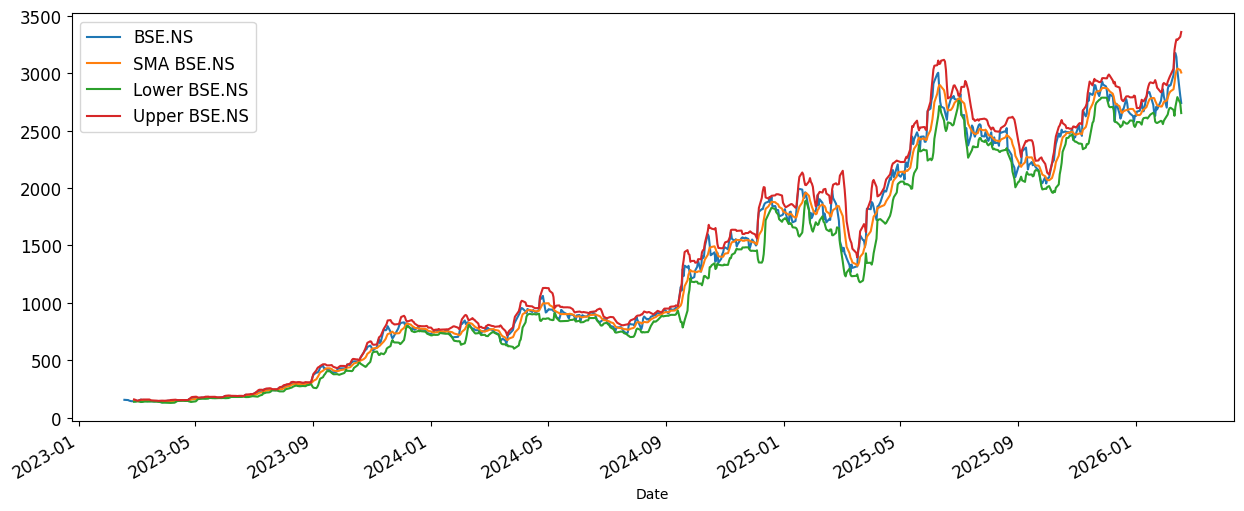

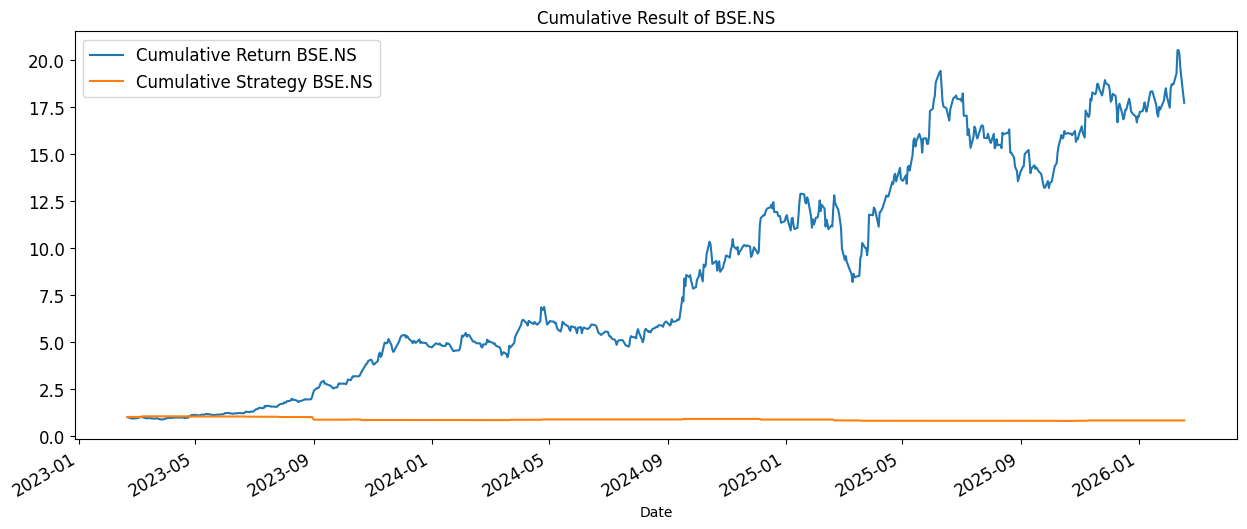

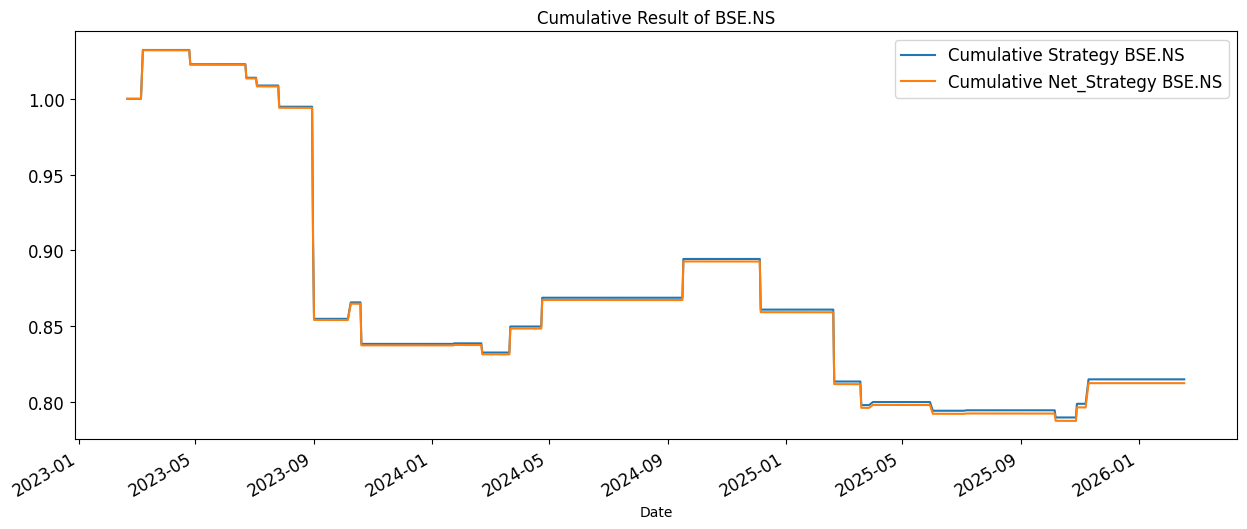

In [134]:
str1.plot_data()

In [ ]:
str1.ann_result()